In [1]:
import pandas as pd
df = pd.read_csv("unclean_sensor_data.csv")
df.head()

,Timestamp,Temperature (°C),Vibration (mm/s),Pressure (bar),Flow Rate (L/min),Efficiency (%)
0,2024-01-01 20:52:00,77.942181,0.435541,3.285961976243364,391.774055,91.099840
1,2024-01-04 06:04:00,77.187531,1.461559,2.1529050080634207,112.836066,67.516033
2,2024-01-02 04:51:00,72.113290,3.267867,2.9445642159116434,252.605450,94.390103
3,2024-01-04 07:02:00,67.450034,1.528595,1.9747629864169236,213.306040,82.082316
4,2024-01-04 03:21:00,91.438806,1.623124,3.1180824564531227,318.441369,83.227378


In [2]:
df.info

<bound method DataFrame.info of                 Timestamp  Temperature (°C)  Vibration (mm/s)  \
0     2024-01-01 20:52:00         77.942181          0.435541   
1     2024-01-04 06:04:00         77.187531          1.461559   
2     2024-01-02 04:51:00         72.113290          3.267867   
3     2024-01-04 07:02:00         67.450034          1.528595   
4     2024-01-04 03:21:00         91.438806          1.623124   
...                   ...               ...               ...   
9995  2024-01-01 12:14:00         67.468926          5.456860   
9996  2024-01-01 03:11:00         70.112623          2.161953   
9997  2024-01-01 06:30:00         76.680766          5.790794   
9998  2024-01-01 14:20:00         72.354437          1.761720   
9999  2024-01-02 13:50:00         73.911435          0.362384   

          Pressure (bar)  Flow Rate (L/min)  Efficiency (%)  
0      3.285961976243364         391.774055       91.099840  
1     2.1529050080634207         112.836066       67.516033  
2

In [3]:
df.isnull().sum()

Timestamp            500
Temperature (°C)     299
Vibration (mm/s)       0
Pressure (bar)       200
Flow Rate (L/min)      0
Efficiency (%)       250
dtype: int64

In [8]:
df.dtypes

Timestamp             object
Temperature (°C)     float64
Vibration (mm/s)     float64
Pressure (bar)        object
Flow Rate (L/min)    float64
Efficiency (%)       float64
dtype: object

In [9]:
df["Pressure (bar)"] = pd.to_numeric(df["Pressure (bar)"], errors="coerce")

In [10]:
df.dtypes

Timestamp             object
Temperature (°C)     float64
Vibration (mm/s)     float64
Pressure (bar)       float64
Flow Rate (L/min)    float64
Efficiency (%)       float64
dtype: object

In [11]:
df["Temperature (°C)"] = df["Temperature (°C)"].fillna(df["Temperature (°C)"].median())

df["Pressure (bar)"] = df["Pressure (bar)"].fillna(df["Pressure (bar)"].median())

df["Efficiency (%)"] = df["Efficiency (%)"].fillna(df["Efficiency (%)"].median())

In [12]:
df.isnull().sum()

Timestamp            500
Temperature (°C)       0
Vibration (mm/s)       0
Pressure (bar)         0
Flow Rate (L/min)      0
Efficiency (%)         0
dtype: int64

In [13]:
df.drop("Timestamp",axis=1,inplace=True)

In [14]:
df.isnull().sum()

Temperature (°C)     0
Vibration (mm/s)     0
Pressure (bar)       0
Flow Rate (L/min)    0
Efficiency (%)       0
dtype: int64

In [15]:
from sklearn.ensemble import IsolationForest
X=

In [16]:
clf = IsolationForest(contamination=0.05,random_state=42)
df["Anomaly"] = clf.fit_predict(df)

In [17]:
df["Anomaly"].value_counts()

Anomaly
 1    9500
-1     500
Name: count, dtype: int64

In [19]:
Anomaly_count = (df["Anomaly"]==-1).sum()

In [20]:
print("Number of Anomaly",Anomaly_count)

Number of Anomaly 500


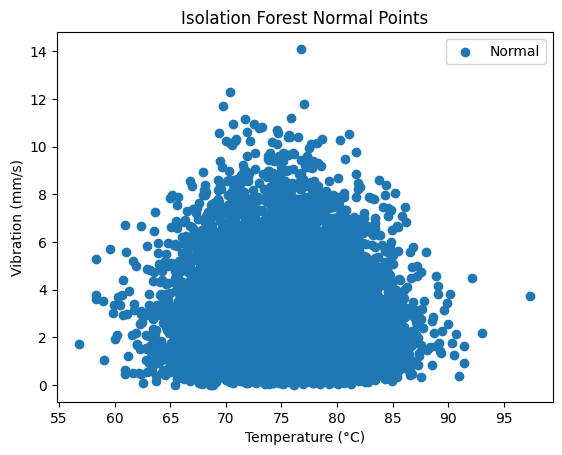

In [26]:
import  matplotlib.pyplot as plt
plt.scatter(
    df[df["Anomaly"] == 1]["Temperature (°C)"],
    df[df["Anomaly"] == 1]["Vibration (mm/s)"],
    label="Normal"
)
plt.title("Isolation Forest Normal Points")
plt.xlabel("Temperature (°C)")
plt.ylabel("Vibration (mm/s)")
plt.legend()
plt.show()

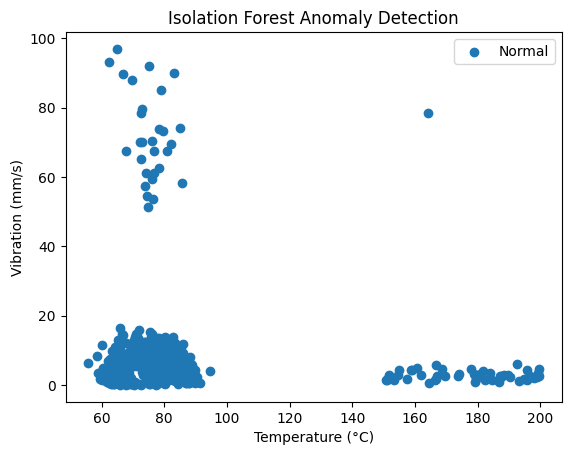

In [27]:
plt.scatter(
    df[df["Anomaly"] == -1]["Temperature (°C)"],
    df[df["Anomaly"] == -1]["Vibration (mm/s)"],
    label = "Normal"
)
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Temperature (°C)")
plt.ylabel("Vibration (mm/s)")
plt.legend()
plt.show()